In [1]:
from sklearn.svm import SVC
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import trange,tqdm
import pickle
import matplotlib.pyplot as plt
from math import ceil
import scipy
import scipy.signal
import itertools
import sys, os
import scipy.stats as sts
from scipy.stats import sem
import numpy.random as npr
import pandas as pd
from typing import List, Tuple
from sklearn.preprocessing import StandardScaler
import ast
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from matplotlib.ticker import MaxNLocator

In [2]:
with open('C:/Users/shahe/Desktop/Lubna/PHD_NEURO/INM/MONKEY_DATA/DATA/Classification/classification_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [2]:
# Now try reading it
with open('C:/Users/shahe/PycharmProjects/distributed_SD/Data/filtered_mocol_categorization_bin_0.05.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
for i, df in enumerate(data['trial']):
    if 'chosenResponse' in df.columns and 'expectedResponse' in df.columns:
        def clean(val):
            if isinstance(val, np.ndarray):
                return str(val[0]) if len(val) > 0 else None
            return str(val) if val is not None else None

        df['chosenResponse'] = df['chosenResponse'].apply(clean)
        df['expectedResponse'] = df['expectedResponse'].apply(clean)
        df['color'] = df['color']/90
        df['direction'] = df['direction']/90
        data['trial'][i] = df  # Save cleaned DataFrame back
    else:
        print(f"Session {i}: Missing required columns.")


for i, df in enumerate(data['trial']):
    if 'chosenResponse' in df.columns and 'expectedResponse' in df.columns:
        # Map values
        df['chosenResponse'] = df['chosenResponse'].map({'L': 1, 'R': 0})
        df['expectedResponse'] = df['expectedResponse'].map({'L': 1, 'R': 0})
        data['trial'][i] = df  # Save updated DataFrame back
    else:
        print(f"Session {i}: Missing required columns.")

for i, df in enumerate(data['trial']):
    if 'rule' in df.columns:
        # Extract the string from the array and map it to numeric
        df['rule'] = df['rule'].apply(
            lambda x: 1 if isinstance(x, (list, np.ndarray)) and 'color' in x else
                      -1 if isinstance(x, (list, np.ndarray)) and 'motion' in x else
                      np.nan  # fallback for unexpected format
        )
        data['trial'][i] = df  # Update cleaned DataFrame

In [4]:
data = data['trial']

In [5]:

def keep_consecutive_trials(df, trial_col='trial'):
    df = df.sort_values(trial_col).copy()
    is_consecutive = df[trial_col].diff().eq(1)  # True if current trial follows previous by 1
    return df.loc[is_consecutive].copy()


In [6]:
def process_session_data(df):
    """
    Process a single session DataFrame.
    Cleans and adds derived variables for analysis, including cue encoding.
    """
    df = df.copy()
    scaler = StandardScaler()

    # Basic columns
    df['intercept'] = 1

    # Raw stimulus variables
    df['color_z'] = df['color']
    df['direction_z'] = df['direction']

    # Previous trial variables
    df['p_color_z'] = df['color_z'].shift(1)
    df['p_direction_z'] = df['direction_z'].shift(1)
    df['prev_response'] = df['chosenResponse'].shift(1)

    # relevant stimulus when rule is 1 --> color and when rule is -1 --> motion
    df['relevant_stim'] = df.apply(
        lambda row: row['color_z'] if row['rule'] == 1 else row['direction_z'], axis=1
    )
    df['irrelevant_stim'] = df.apply(
        lambda row: row['direction_z'] if row['rule'] == 1 else row['color_z'], axis=1
    )

    df['prev_relevant_stim'] = df['relevant_stim'].shift(1)
    df['prev_irrelevant_stim'] = df['irrelevant_stim'].shift(1)
    df['dist_prev_current_relevant'] = abs(df['relevant_stim'] - df['prev_relevant_stim'])
    df['dist_prev_current_irrelevant'] = abs(df['irrelevant_stim'] - df['prev_irrelevant_stim'])


    # Rule/context
    df['context'] = df['rule']
   
    df['prob_color'] = np.where(df['context'] == 1, 1, 0)
    df['prob_motion'] = np.where(df['context'] == 0, 1, 0)
    df['prev_context'] = df['context'].shift(1)

    # Distances between trials
    df['dist_prev_current_color'] = abs(df['color_z'] - df['p_color_z'])
    df['dist_prev_current_motion'] = abs(df['direction_z'] - df['p_direction_z'])

    df['color_ctx'] = df['color_z']*df['context']
    df['direction_ctx'] = df['direction_z']*df['context']

    df['prev_res_ctx'] = df['prev_response']*df['context']

    # select trials where rule = 1
    #df = df[df['rule'] == 1].copy()  # only keep color trials

    # let's create trial called reward if ['numRewards'] > 0 --> 1, other wise 0
    df['numRewards'] = df['numRewards'].fillna(0)  # ensure no NaNs --> neutral trials are considered as no reward trials
    df['reward'] = np.where(df['numRewards'] > 0, 1, 0)  # 1 if reward, else 0
    df['prev_reward'] = df['reward'].shift(1).fillna(0)  # previous trial reward

    # let's create a column called error trial, whcih comes from df['chosenResponse'] != df['expectedResponse'], excluding nan tirals from expectedResponse
    df['errorTrial'] = np.where(
        (df['chosenResponse'] != df['expectedResponse']) & df['expectedResponse'].notna(),
        1, 0
    )

    # Switch vs repeat
    df['is_switch'] = np.where(
        df['prev_context'].isna(), 
        0, 
        (df['context'] != df['prev_context']).astype(int)
    )



    # Filter trials: good timing only
    good_mask = df['badTimingTrials'] == 0
    df_filtered = df[good_mask].reset_index(drop=True)

    # Normalize reaction time
    df_filtered['reactionTime_z'] = scaler.fit_transform(df_filtered[['reactionTime']])

    # let's keep correct trials
    #df_filtered = df_filtered[df_filtered['errorTrial'] == 0].reset_index(drop=True)

    

    # One-hot encode cue (4 categories)
    cue_dummies = pd.get_dummies(df_filtered['cue'], prefix='cue', drop_first=False)
    df_filtered = pd.concat([df_filtered, cue_dummies], axis=1)

    return df_filtered


In [7]:

def prepare_data_for_glmhmm_sessionwise(data):
    """
    Prepares input features and responses for HMM-GLM model fitting.
    Returns separate input arrays per session (no concatenation).
    """
    inpts = []
    true_choices = []
    session_lengths = []

    for df in data:
        # Extract features (negated for consistency with logistic loss convention)
        color         = df[['color_z']].fillna(0).to_numpy()
        motion        = df[['direction_z']].fillna(0).to_numpy()
        p_color       = df[['p_color_z']].fillna(0).to_numpy()
        dist_prev_c   = df[['dist_prev_current_color']].fillna(0).to_numpy()
        p_motion      = df[['p_direction_z']].fillna(0).to_numpy()
        dist_prev_m   = df[['dist_prev_current_motion']].fillna(0).to_numpy()
        prev_response = df[['prev_response']].fillna(0).to_numpy()
        color_ctx    = df[['color_ctx']].fillna(0).to_numpy()
        direction_ctx = df[['direction_ctx']].fillna(0).to_numpy()
        prev_res_ctx = df[['prev_res_ctx']].fillna(0).to_numpy()
        context       = df[['context']].fillna(0).to_numpy()
        relevant_stim = df[['relevant_stim']].fillna(0).to_numpy()
        irrelevant_stim = df[['irrelevant_stim']].fillna(0).to_numpy()

        prev_relevant_stim = df[['prev_relevant_stim']].fillna(0).to_numpy()
        prev_irrelevant_stim = df[['prev_irrelevant_stim']].fillna(0).to_numpy()
        dist_prev_current_relevant = df[['dist_prev_current_relevant']].fillna(0).to_numpy()
        dist_prev_current_irrelevant = df[['dist_prev_current_irrelevant']].fillna(0).to_numpy()

        prev_reward = df[['prev_reward']].fillna(0).to_numpy()
        bias          = df[['intercept']].fillna(0).to_numpy()

        is_switch = df[['is_switch']].fillna(0).to_numpy()
        prev_location_reward = df[['prev_response']].fillna(0).to_numpy() * df[['prev_reward']].fillna(0).to_numpy()

        context_prev_resp = df[['prev_response']].fillna(0).to_numpy() * df[['context']].fillna(0).to_numpy()


        # Cue dummies (cue_0, cue_1, cue_2, cue_3)
        cue_cols = [col for col in df.columns if col.startswith('cue_')]
        cue_dummies = df[cue_cols].fillna(0).astype(int).to_numpy()


        # Combine all into feature matrix
        X = np.hstack([
            #color,
            #motion,
            #p_color,
            #p_motion,
            #dist_prev_c,
            #dist_prev_m,
            relevant_stim,
            irrelevant_stim,
            prev_relevant_stim,
            prev_irrelevant_stim, 
            #dist_prev_current_relevant,
            #dist_prev_current_irrelevant,
            prev_response,
            #prev_location_reward,
            #prev_reward,
            #context_prev_resp,
            #color_ctx,
            #direction_ctx,
            #is_switch,
            #context,
            #ue_dummies,
            bias
        ])

        # Response variable
        y = df['chosenResponse'].fillna(0).astype(int).to_numpy().reshape(-1, 1)

        # Save session data
        inpts.append(X)
        true_choices.append(y)
        session_lengths.append(len(df))

    return inpts, true_choices, session_lengths


# Assuming `data` is a list of session DataFrames:
processed_data = [process_session_data(df) for df in data]
inpts, true_choices, session_lengths = prepare_data_for_glmhmm_sessionwise(processed_data)

# Determine input dimensionality
input_dim = inpts[0].shape[1]

In [8]:
def predict_logistic_with_lapses(X, params):
    beta = params[:-2]
    gamma_r = params[-2]
    gamma_l = params[-1]
    logits = X @ beta
    p = 1 / (1 + np.exp(-logits))
    return gamma_l + (1 - gamma_l - gamma_r) * p

def neg_log_likelihood(params, X, y):
    p = predict_logistic_with_lapses(X, params)
    eps = 1e-9
    return -np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

def fit_with_mle(X, y):
    n_features = X.shape[1]
    p0 = [0.1] * n_features + [0.05, 0.05]  # init weights + lapse params
    bounds = [(-10, 10)] * n_features + [(0, 0.49), (0, 0.49)]
    result = minimize(neg_log_likelihood, p0, args=(X, y), method='L-BFGS-B', bounds=bounds)
    if result.success:
        return result.x
    else:
        raise RuntimeError("Fitting failed")

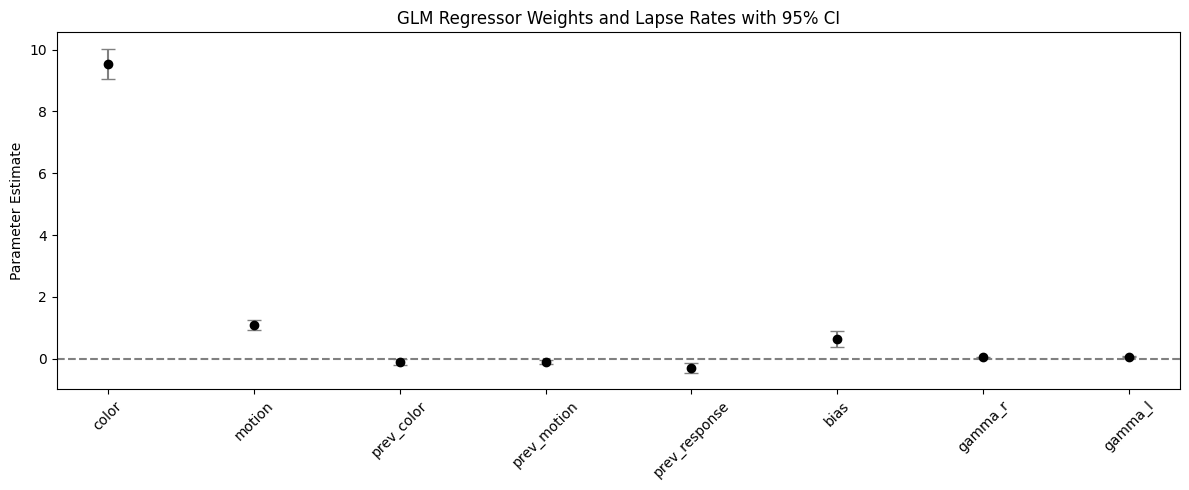

In [9]:
from scipy.optimize import minimize


# Step 3: Fit GLM per session and store full parameter vectors

regressor_labels = [
    "color", "motion", "prev_color",  "prev_motion",  #"dist_prev_col", "dist_prev_mot","prev_rewarded_loc",
    "prev_response",  "bias",    # "color_ctx","direction_ctx", "bias", "context_prev_resp", "color_ctx", "direction_ctx", "prev_reward", "is_switch",
    "gamma_r", "gamma_l"
] # "color_ctx", "direction_ctx", 
'''
regressor_labels = ["relevant_stim", "irrelevant_stim", "prev_relevant_stim", "prev_irrelevant_stim","dist_prev_relevant", "dist_prev_irrelevant",
                    "prev_response", "prev_rewarded_loc", "prev_reward", "bias", "gamma_r", "gamma_l"] # "prev_reward","is_switch"
'''

all_params = []
for X, y in zip(inpts, true_choices):
    y = y.flatten()
    try:
        fitted_params = fit_with_mle(X, y)
        all_params.append(fitted_params)
    except RuntimeError:
        print("MLE failed.")
        all_params.append(np.full(X.shape[1] + 2, np.nan))

# Step 4: Store as DataFrame for easy access
betas_df = pd.DataFrame(all_params, columns=regressor_labels)

# Step 5: Compute group-level stats
mean_params = betas_df.mean(skipna=True)
std_params = betas_df.std(skipna=True)
ci95_params = 1.96 * std_params / np.sqrt(betas_df.notna().sum())

# -------------------------------
# --- Plot: Weights + Lapses ---
# -------------------------------
plt.figure(figsize=(12, 5))
plt.errorbar(
    range(len(mean_params)), mean_params, yerr=ci95_params, fmt='o',
    capsize=5, color='black', ecolor='gray'
)
plt.axhline(0, linestyle='--', color='gray')
plt.xticks(range(len(mean_params)), regressor_labels, rotation=45)
plt.ylabel('Parameter Estimate')
plt.title('GLM Regressor Weights and Lapse Rates with 95% CI')
plt.tight_layout()
plt.show()

In [10]:
betas_df.describe().T[['mean', 'std', 'count']].round(3)


,mean,std,count
color,9.533,1.708,45.0
motion,1.094,0.549,45.0
prev_color,-0.113,0.340,45.0
prev_motion,-0.099,0.187,45.0
prev_response,-0.291,0.551,45.0
bias,0.649,0.904,45.0
gamma_r,0.054,0.047,45.0
gamma_l,0.061,0.046,45.0


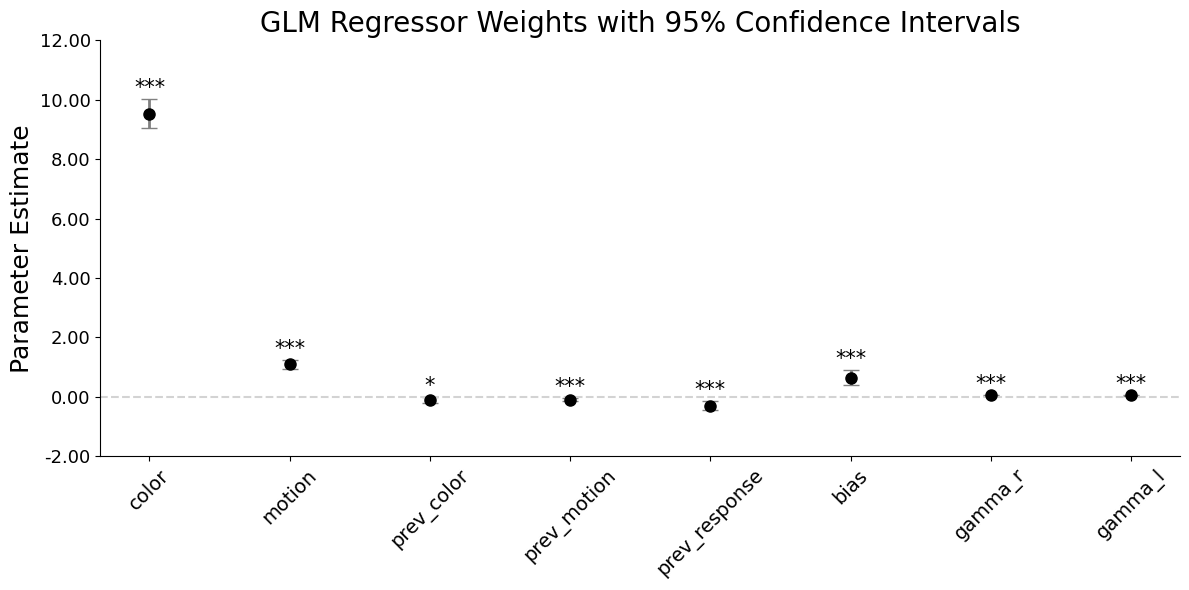

In [11]:
# --- Compute standard error (SE) ---
n = betas_df.notna().sum()
se = ci95_params / 1.96  # CI = 1.96 * SE

# --- Compute z-scores and p-values ---
z_scores = mean_params / se
p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))  # two-tailed

# --- Assign significance labels ---
def get_sig_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

sig_labels = [get_sig_label(p) for p in p_values]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot error bars
ax.errorbar(
    range(len(mean_params)), mean_params, yerr=ci95_params,
    fmt='o', capsize=6, markersize=8,
    color='black', ecolor='gray', lw=2
)

# Annotate with significance stars
for i, (y_val, err, label) in enumerate(zip(mean_params, ci95_params, sig_labels)):
    y = y_val + err
    ax.text(i, y + 0.03, label, ha='center', va='bottom',
            fontsize=15, color='black' if label != 'ns' else 'gray')

# Formatting
ax.axhline(0, linestyle='--', color='lightgray', linewidth=1.5)
ax.set_ylabel("Parameter Estimate", fontsize=18)
ax.set_xticks(range(len(mean_params)))
ax.set_xticklabels(regressor_labels, rotation=45, fontsize=14)
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.set_title("GLM Regressor Weights with 95% Confidence Intervals", fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("glm_weights_significance.svg", format='svg', dpi=300)
plt.show()


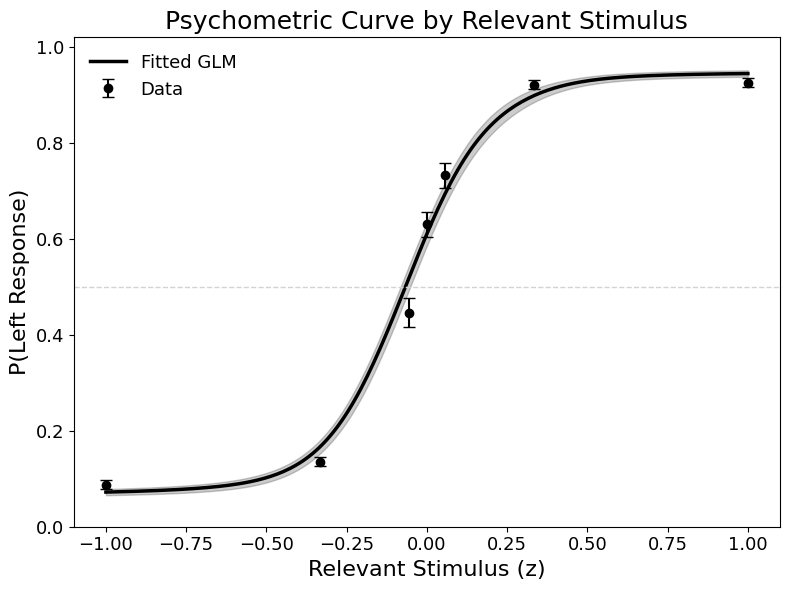

In [14]:
# Add `relevant_stim` to all sessions
for df in processed_data:
    df['relevant_stim'] = np.where(df['rule'] == 1, df['color_z'], df['direction_z'])

# X-axis range for the psychometric curve
stim_range = np.linspace(-1, 1, 200)

all_preds = []
empirical_counts = {}

for df in processed_data:
    df = df.copy()

    # --- Design matrix ---
    relevant      = df[['relevant_stim']].fillna(0).to_numpy()
    motion        = df[['direction_z']].fillna(0).to_numpy()
    p_color       = df[['p_color_z']].fillna(0).to_numpy()
    p_motion      = df[['p_direction_z']].fillna(0).to_numpy()
    prev_response = df[['prev_response']].fillna(0).to_numpy()
    color_ctx     = df[['color_ctx']].fillna(0).to_numpy()
    direction_ctx = df[['direction_ctx']].fillna(0).to_numpy()
    bias          = df[['intercept']].fillna(0).to_numpy()

    # Combine all predictors
    X = np.hstack([
        relevant, motion, p_color,
        p_motion, prev_response,
        color_ctx, direction_ctx, bias
    ])
    y = df['chosenResponse'].fillna(0).astype(int).to_numpy().flatten()

    if np.all(y == y[0]) or len(np.unique(y)) < 2:
        continue

    try:
        # Fit logistic model
        params = fit_with_mle(X, y)

        # Predict curve across stimulus range
        X_pred = np.tile(np.mean(X, axis=0), (len(stim_range), 1))
        X_pred[:, 0] = stim_range  # vary only relevant stim
        y_pred = predict_logistic_with_lapses(X_pred, params)
        all_preds.append(y_pred)
    except RuntimeError:
        continue

    # Empirical values by relevant stim
    for val, grp in df.groupby('relevant_stim'):
        empirical_counts.setdefault(val, []).append(grp['chosenResponse'].mean())

# --- Aggregate fitted curves ---
all_preds = np.array(all_preds)
mean_fit = np.nanmean(all_preds, axis=0)
sem_fit = np.nanstd(all_preds, axis=0) / np.sqrt(all_preds.shape[0])

# --- Empirical stats ---
sorted_stim = sorted(empirical_counts.keys())
mean_emp = [np.mean(empirical_counts[val]) for val in sorted_stim]
sem_emp = [np.std(empirical_counts[val]) / np.sqrt(len(empirical_counts[val])) for val in sorted_stim]

# --- Plotting ---
plt.figure(figsize=(8, 6))

plt.plot(stim_range, mean_fit, color='black', lw=2.5, label='Fitted GLM')
plt.fill_between(stim_range, mean_fit - sem_fit, mean_fit + sem_fit, color='black', alpha=0.2)

plt.errorbar(sorted_stim, mean_emp, yerr=sem_emp, fmt='o', color='black', capsize=4, label='Data')

plt.xlabel("Relevant Stimulus (z)", fontsize=16)
plt.ylabel("P(Left Response)", fontsize=16)
plt.axhline(0.5, linestyle='--', color='lightgray', lw=1)
plt.ylim(0, 1.02)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13, frameon=False)
plt.title("Psychometric Curve by Relevant Stimulus", fontsize=18)
plt.tight_layout()
plt.show()



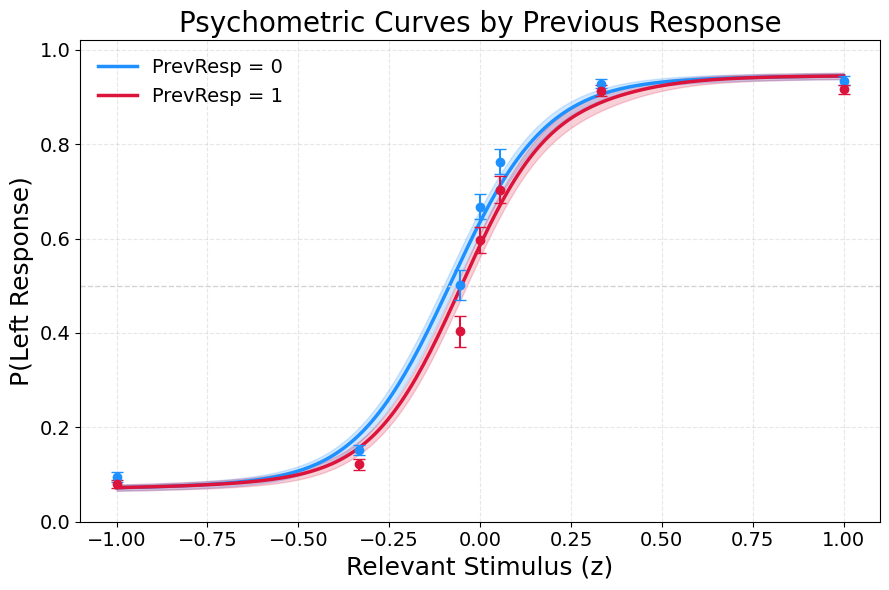

In [15]:
# Add `relevant_stim` if not already added
for df in processed_data:
    df['relevant_stim'] = np.where(df['rule'] == 1, df['color_z'], df['direction_z'])

stim_range = np.linspace(-1, 1, 200)
all_preds_0 = []
all_preds_1 = []

empirical_0 = {}
empirical_1 = {}

for df in processed_data:
    df = df.copy()

    # Design matrix
    relevant      = df[['relevant_stim']].fillna(0).to_numpy()
    motion        = df[['direction_z']].fillna(0).to_numpy()
    p_color       = df[['p_color_z']].fillna(0).to_numpy()
    p_motion      = df[['p_direction_z']].fillna(0).to_numpy()
    prev_response = df[['prev_response']].fillna(0).to_numpy()
    color_ctx     = df[['color_ctx']].fillna(0).to_numpy()
    direction_ctx = df[['direction_ctx']].fillna(0).to_numpy()
    bias          = df[['intercept']].fillna(0).to_numpy()

    X = np.hstack([
        relevant, motion, p_color,
        p_motion, prev_response,
        color_ctx, direction_ctx, bias
    ])
    y = df['chosenResponse'].fillna(0).astype(int).to_numpy().flatten()

    if np.all(y == y[0]) or len(np.unique(y)) < 2:
        continue

    try:
        params = fit_with_mle(X, y)

        # --- Predict for prev_response = 0 ---
        X0 = np.tile(np.mean(X, axis=0), (len(stim_range), 1))
        X0[:, 0] = stim_range          # vary relevant_stim
        X0[:, 4] = 0                   # set prev_response = 0
        y_pred_0 = predict_logistic_with_lapses(X0, params)
        all_preds_0.append(y_pred_0)

        # --- Predict for prev_response = 1 ---
        X1 = np.tile(np.mean(X, axis=0), (len(stim_range), 1))
        X1[:, 0] = stim_range
        X1[:, 4] = 1                   # set prev_response = 1
        y_pred_1 = predict_logistic_with_lapses(X1, params)
        all_preds_1.append(y_pred_1)

    except RuntimeError:
        continue

    # Empirical split by prev_response
    for val, grp in df.groupby(['relevant_stim', 'prev_response']):
        stim_val, prev_resp = val
        if prev_resp == 0:
            empirical_0.setdefault(stim_val, []).append(grp['chosenResponse'].mean())
        elif prev_resp == 1:
            empirical_1.setdefault(stim_val, []).append(grp['chosenResponse'].mean())

# Aggregate fitted curves
mean_fit_0 = np.nanmean(all_preds_0, axis=0)
sem_fit_0 = np.nanstd(all_preds_0, axis=0) / np.sqrt(len(all_preds_0))

mean_fit_1 = np.nanmean(all_preds_1, axis=0)
sem_fit_1 = np.nanstd(all_preds_1, axis=0) / np.sqrt(len(all_preds_1))

# Empirical means and sem
sorted_stim_0 = sorted(empirical_0.keys())
mean_emp_0 = [np.mean(empirical_0[s]) for s in sorted_stim_0]
sem_emp_0 = [np.std(empirical_0[s]) / np.sqrt(len(empirical_0[s])) for s in sorted_stim_0]

sorted_stim_1 = sorted(empirical_1.keys())
mean_emp_1 = [np.mean(empirical_1[s]) for s in sorted_stim_1]
sem_emp_1 = [np.std(empirical_1[s]) / np.sqrt(len(empirical_1[s])) for s in sorted_stim_1]

# --- Plot ---
plt.figure(figsize=(9, 6))

# Fitted curves
plt.plot(stim_range, mean_fit_0, label='PrevResp = 0', color='dodgerblue', lw=2.5)
plt.fill_between(stim_range, mean_fit_0 - sem_fit_0, mean_fit_0 + sem_fit_0, color='dodgerblue', alpha=0.2)

plt.plot(stim_range, mean_fit_1, label='PrevResp = 1', color='crimson', lw=2.5)
plt.fill_between(stim_range, mean_fit_1 - sem_fit_1, mean_fit_1 + sem_fit_1, color='crimson', alpha=0.2)

# Empirical
plt.errorbar(sorted_stim_0, mean_emp_0, yerr=sem_emp_0, fmt='o', color='dodgerblue', capsize=4)
plt.errorbar(sorted_stim_1, mean_emp_1, yerr=sem_emp_1, fmt='o', color='crimson', capsize=4)

# Aesthetics
plt.xlabel("Relevant Stimulus (z)", fontsize=18)
plt.ylabel("P(Left Response)", fontsize=18)
plt.axhline(0.5, linestyle='--', color='lightgray', lw=1)
plt.ylim(0, 1.02)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, frameon=False)
plt.title("Psychometric Curves by Previous Response", fontsize=20)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [35]:
inpts = inpts_rex
true_choices =  choices_rex

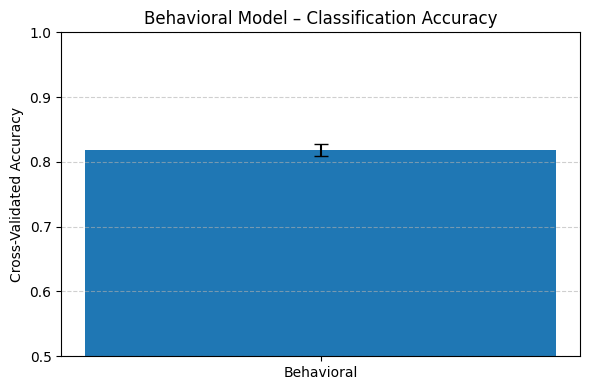

In [36]:
def compute_cv_accuracy(X, y, k=5):
    """
    Compute cross-validated accuracy for logistic regression with asymmetric lapses.

    Parameters:
        X: [n_samples, n_features] numpy array
        y: [n_samples] binary response vector
        k: int, number of folds for cross-validation

    Returns:
        float: mean classification accuracy across folds
    """
    if len(np.unique(y)) < 2:
        return np.nan

    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    accuracies = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        try:
            params = fit_with_mle(X_train, y_train)
            probs = predict_logistic_with_lapses(X_test, params)
            y_pred = (probs >= 0.5).astype(int)
            acc = np.mean(y_pred == y_test)
            accuracies.append(acc)
        except RuntimeError:
            accuracies.append(np.nan)

    return np.nanmean(accuracies)
accuracies_behav = []

for X, y in zip(inpts, true_choices):
    acc = compute_cv_accuracy(X, y.flatten(), k=5)
    accuracies_behav.append(acc)

# Convert to DataFrame for plotting
import pandas as pd
import matplotlib.pyplot as plt

acc_df = pd.DataFrame({'Behavioral Accuracy': accuracies_behav})

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['Behavioral'], [acc_df.mean().values[0]], yerr=acc_df.sem().values[0], capsize=5)
plt.ylabel('Cross-Validated Accuracy')
plt.title('Behavioral Model – Classification Accuracy')
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [38]:
np.mean(acc_df['Behavioral Accuracy']), np.std(acc_df['Behavioral Accuracy']), acc_df['Behavioral Accuracy'].sem()


(np.float64(0.8178457396401695),
 0.03603842969745345,
 np.float64(0.0093050825361136))

In [44]:
def cross_validate_asym_lapse(X, y, n_splits=5, random_state=0):
    """
    Cross-validated accuracy and pseudo-R² for asymmetric lapse logistic model.
    """
    y = np.asarray(y).ravel()
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    y_true_all = []
    y_pred_all = []
    acc_scores = []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Fit model on training set
        try:
            params = fit_with_mle(X_train, y_train)
        except RuntimeError:
            # If fit fails, skip this fold
            continue

        # Predict probabilities on test set
        y_pred_prob = predict_logistic_with_lapses(X_test, params)

        # Store out-of-fold predictions
        y_true_all.append(y_test)
        y_pred_all.append(y_pred_prob)

        # Classification accuracy at threshold 0.5
        y_pred_class = (y_pred_prob >= 0.5).astype(int)
        acc_scores.append(accuracy_score(y_test, y_pred_class))

    # Concatenate across folds
    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    # Cross-validated accuracy
    acc_mean = np.mean(acc_scores)
    acc_std = np.std(acc_scores)

    # Pseudo-R² using squared error explained variance
    ss_res = np.sum((y_true_all - y_pred_all) ** 2)
    ss_tot = np.sum((y_true_all - np.mean(y_true_all)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return {
        "accuracy_mean": acc_mean,
        "accuracy_std": acc_std,
        "pseudo_r2": r2,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
    }

# --- Apply to pooled trials ---
X_all = np.vstack(inpts)
y_all = np.vstack(true_choices).ravel()

cv_results = cross_validate_asym_lapse(X_all, y_all, n_splits=5)

print("=== Cross-validated performance (Asym Lapse GLM, all trials) ===")
print(f"Accuracy: {cv_results['accuracy_mean']:.3f} ± {cv_results['accuracy_std']:.3f}")
print(f"Pseudo-R²: {cv_results['pseudo_r2']:.3f}")


=== Cross-validated performance (Asym Lapse GLM, all trials) ===
Accuracy: 0.708 ± 0.001
Pseudo-R²: 0.265


In [34]:
# --- Robust scalar extractor for weird nested numpy/list wrappers ---
def _extract_scalar(x):
    """
    Unwrap values like array(array(['paula'], dtype='<U5'), dtype=object) -> 'paula'
    or array(1235, dtype=uint16) -> 1235.
    Keeps unwrapping while size==1 for np.ndarray or len==1 for lists.
    """
    while True:
        if isinstance(x, np.ndarray):
            if x.shape == ():               # 0-d array
                x = x.item()
            elif x.size == 1:               # 1-element array
                x = x.item()
            else:
                break
        elif isinstance(x, (list, tuple)) and len(x) == 1:
            x = x[0]
        else:
            break
    return x

def get_subject_from_session_meta(sess_meta):
    """
    sess_meta is a dict with numpy arrays, e.g. sess_meta['subject'] is a nested array.
    Returns lowercase subject string.
    """
    if not isinstance(sess_meta, dict):
        raise ValueError("Expected dict in data['session'][i].")
    if 'subject' not in sess_meta:
        raise ValueError("No 'subject' key in data['session'][i].")

    raw = sess_meta['subject']
    subj = _extract_scalar(raw)
    return str(subj).strip().lower()

# --- Verify aligned lengths ---
n_sessions_trial = len(data['trial'])
n_sessions_meta  = len(data['session'])
if n_sessions_trial != n_sessions_meta:
    raise ValueError(f"Length mismatch: data['trial']={n_sessions_trial} vs data['session']={n_sessions_meta}")

# --- Collect indices per subject using data['session'] ---
paula_idx, rex_idx = [], []
for i in range(n_sessions_meta):
    subj = get_subject_from_session_meta(data['session'][i])
    if subj == "paula":
        paula_idx.append(i)
    elif subj == "rex":
        rex_idx.append(i)

print(f"Found {len(paula_idx)} Paula sessions and {len(rex_idx)} Rex sessions.")

# --- Build subject-specific trial DataFrame lists from data['trial'] ---
paula_sessions = [data['trial'][i] for i in paula_idx]
rex_sessions   = [data['trial'][i] for i in rex_idx]

# --- Process per session with your existing function ---
processed_paula = [process_session_data(df) for df in paula_sessions] if paula_sessions else []
processed_rex   = [process_session_data(df) for df in rex_sessions]   if rex_sessions   else []

# --- Prepare GLM-HMM inputs (sessionwise) ---
if processed_paula:
    inpts_paula, choices_paula, lens_paula = prepare_data_for_glmhmm_sessionwise(processed_paula)
    inpts_paula_concat   = [np.concatenate(inpts_paula, axis=0)]
    choices_paula_concat = [np.concatenate(choices_paula, axis=0)]
    input_dim_paula = inpts_paula_concat[0].shape[1]
    print("PAULA — Num sessions:", len(inpts_paula))
    print("PAULA — Trials per session:", lens_paula)
else:
    inpts_paula_concat, choices_paula_concat, lens_paula, input_dim_paula = [], [], [], None
    print("PAULA — No sessions found.")

if processed_rex:
    inpts_rex, choices_rex, lens_rex = prepare_data_for_glmhmm_sessionwise(processed_rex)
    inpts_rex_concat   = [np.concatenate(inpts_rex, axis=0)]
    choices_rex_concat = [np.concatenate(choices_rex, axis=0)]
    input_dim_rex = inpts_rex_concat[0].shape[1]
    print("REX   — Num sessions:", len(inpts_rex))
    print("REX   — Trials per session:", lens_rex)
else:
    inpts_rex_concat, choices_rex_concat, lens_rex, input_dim_rex = [], [], [], None
    print("REX   — No sessions found.")

# --- Shared modeling hyperparameters ---
num_states     = 3
obs_dim        = 1
num_categories = 2
N_iters        = 3000
tolerance      = 10**-0.15

# --- Initialize one HMM per subject (only if that subject exists) ---
models = {}
if input_dim_paula is not None:
    models["paula"] = ssm.HMM(num_states, obs_dim, input_dim_paula,
                              observations="input_driven_obs", transitions="standard")
if input_dim_rex is not None:
    models["rex"] = ssm.HMM(num_states, obs_dim, input_dim_rex,
                            observations="input_driven_obs", transitions="standard")

# Example to fit Paula:
# if "paula" in models:
#     new_glmhmm_paula = models["paula"]
#     # Fit using inpts_paula_concat, choices_paula_concat, lens_paula, N_iters, tolerance, etc.


Found 29 Paula sessions and 16 Rex sessions.
PAULA — Num sessions: 29
PAULA — Trials per session: [1151, 1338, 1082, 1222, 721, 1457, 1511, 1289, 1110, 1227, 1576, 1597, 1291, 1228, 1322, 1338, 986, 1577, 1336, 1493, 1298, 1789, 1579, 1510, 883, 1601, 1224, 1303, 1148]
REX   — Num sessions: 16
REX   — Trials per session: [1381, 1440, 1096, 1457, 969, 1321, 891, 1404, 1164, 1084, 1186, 1084, 1212, 1198, 1020, 1272]
